<a href="https://colab.research.google.com/github/MaryumHayat/Internship/blob/main/Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# @title
# STAGE 1: Setup & Library Collection

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

%matplotlib inline
sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


In [10]:
# STAGE 2: Data Collection

try:
    df = pd.read_csv("/Sleep_health_and_lifestyle_dataset.csv")
    print("Dataset loaded successfully!")
    print(f"Shape of the dataset: {df.shape}")
except FileNotFoundError:
    print("Dataset not found. Please check file path.")

df.head()

Dataset loaded successfully!
Shape of the dataset: (374, 13)


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [11]:
# STAGE 3: Data Preparation & Cleaning

print("--- Check for Null Values ---")
print(df.isnull().sum())

# Drop useless ID column
if 'Person ID' in df.columns:
    df = df.drop(columns=['Person ID'])

# Remove rows with missing target
df = df.dropna(subset=['Sleep Disorder'])

# Fill numeric nulls
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

print("\nData after cleaning stage:")
df.head()

--- Check for Null Values ---
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

Data after cleaning stage:


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
16,Female,29,Nurse,6.5,5,40,7,Normal Weight,132/87,80,4000,Sleep Apnea


In [12]:
# STAGE 4: Feature Engineering

df_features = df.copy()

# Encode categorical variables
categorical_cols = df_features.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('Sleep Disorder')

df_features = pd.get_dummies(df_features, columns=categorical_cols, drop_first=True) # convrt string into binary

# Encode target
le_target = LabelEncoder()
df_features['Sleep Disorder'] = le_target.fit_transform(df_features['Sleep Disorder'])

# Feature Engineering
df_features['Sleep_Efficiency'] = df_features['Quality of Sleep'] / (df_features['Sleep Duration'] + 1e-5)
df_features['Stress_Impact'] = df_features['Stress Level'] * df_features['Heart Rate']

# Split X and y
X = df_features.drop(columns=['Sleep Disorder'])
y = df_features['Sleep Disorder']

print("Features (X) headers passed to training:")
print(X.columns.tolist())

print("\nClass mappings for Target (y):")
for index, class_label in enumerate(le_target.classes_):
    print(f"Code {index} -> {class_label}")

Features (X) headers passed to training:
['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps', 'Gender_Male', 'Occupation_Doctor', 'Occupation_Engineer', 'Occupation_Lawyer', 'Occupation_Nurse', 'Occupation_Sales Representative', 'Occupation_Salesperson', 'Occupation_Scientist', 'Occupation_Software Engineer', 'Occupation_Teacher', 'BMI Category_Normal Weight', 'BMI Category_Obese', 'BMI Category_Overweight', 'Blood Pressure_120/80', 'Blood Pressure_125/80', 'Blood Pressure_129/84', 'Blood Pressure_130/85', 'Blood Pressure_130/86', 'Blood Pressure_131/86', 'Blood Pressure_132/87', 'Blood Pressure_135/88', 'Blood Pressure_135/90', 'Blood Pressure_139/91', 'Blood Pressure_140/90', 'Blood Pressure_140/95', 'Blood Pressure_142/92', 'Sleep_Efficiency', 'Stress_Impact']

Class mappings for Target (y):
Code 0 -> Insomnia
Code 1 -> Sleep Apnea


In [13]:
# STAGE 5: Training & Evaluation

from sklearn.ensemble import GradientBoostingClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Training shape: {X_train.shape}, Test shape: {X_test.shape}")

# Improved Gradient Boosting
gb_base = GradientBoostingClassifier(
    n_estimators=150,  # 150 decision trees
    learning_rate=0.05,  # speed of model to learn
    max_depth=4,
    random_state=42
)

gb_base.fit(X_train, y_train)  # learning function

y_pred_base = gb_base.predict(X_test)

print(f"Baseline Test Accuracy: {accuracy_score(y_test, y_pred_base) * 100:.2f}%") # accuracy of simple stage 1

Training shape: (116, 35), Test shape: (39, 35)
Baseline Test Accuracy: 89.74%


In [14]:
# STAGE 6: Hyperparameter Tuning

param_grid = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5],  # no. of samples each node should have
    'subsample': [0.8, 1.0]  # each tree sees 80% of data
}

print("Starting Hyperparameter Tuning Optimization...")

grid_search = GridSearchCV(  # muliple combination 3x3x3x2x2=106, and it will test each of combination.
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,   # 2 chunks for traing and 1 chunk for testing
    scoring='f1_macro',
    n_jobs=-1    # use all available processor core for parallel processing
)

grid_search.fit(X_train, y_train)  # it will train all combination

best_model = grid_search.best_estimator_  # extracts model with highest f1 score

print(f"Optimal Hyperparameters Found: {grid_search.best_params_}")

Starting Hyperparameter Tuning Optimization...
Optimal Hyperparameters Found: {'learning_rate': 0.03, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100, 'subsample': 1.0}


================ CLASSIFICATION AUDIT REPORT ================
              precision    recall  f1-score   support

    Insomnia       0.89      0.89      0.89        19
 Sleep Apnea       0.90      0.90      0.90        20

    accuracy                           0.90        39
   macro avg       0.90      0.90      0.90        39
weighted avg       0.90      0.90      0.90        39



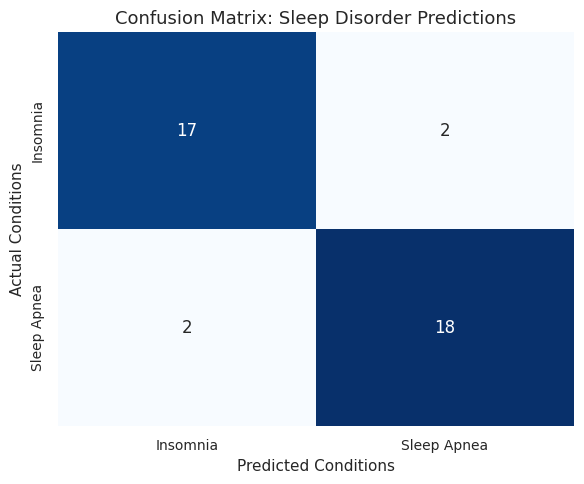

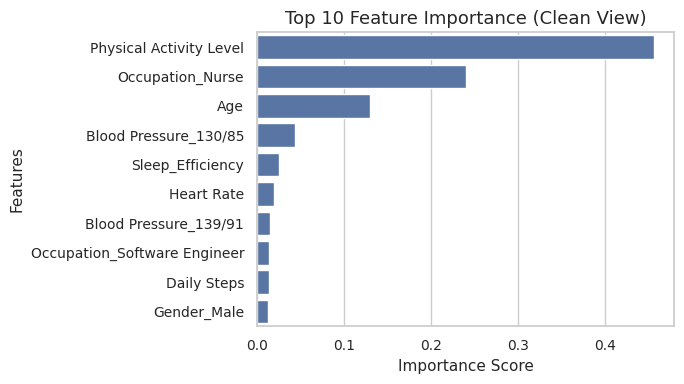

In [15]:
# STAGE 7: Evaluation Metrics & Diagnostic Audits

y_pred = best_model.predict(X_test)

print("================ CLASSIFICATION AUDIT REPORT ================")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=le_target.classes_,
    yticklabels=le_target.classes_,
    annot_kws={"size": 12}
)

plt.title('Confusion Matrix: Sleep Disorder Predictions', fontsize=13)
plt.ylabel('Actual Conditions', fontsize=11)
plt.xlabel('Predicted Conditions', fontsize=11)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

# Get feature importance
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Select TOP 10 features only
top_n = 10
top_features = X.columns[indices][:top_n]
top_importances = importances[indices][:top_n]

plt.figure(figsize=(7, 4))

sns.barplot(
    x=top_importances,
    y=top_features
)

plt.title("Top 10 Feature Importance (Clean View)", fontsize=13)
plt.xlabel("Importance Score", fontsize=11)
plt.ylabel("Features", fontsize=11)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

In [16]:
import pickle

# Save model
with open("sleep_disorder_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save label encoder (VERY IMPORTANT)
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le_target, f)

# Save feature columns (to align input later)
with open("feature_columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

print("Model saved successfully!")

Model saved successfully!
